In [ ]:
# Data collection command:
# `python comet_download.py --project=core-transient-problem-variations --n_threads=8`

In [1]:
from collections import defaultdict
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.analysis_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
save_path = 'figures/'
config_data_path = 'data/core-transient-problem-variations_params.csv'
run_data_path = 'data/core-transient-problem-variations_metrics.csv'

config_dfs, run_dfs = load_experiment_data(config_data_path, run_data_path)
# del config_dfs[np.nan], run_dfs[np.nan]

{k: len(v) for k, v in config_dfs.items()}

{'change_type': 150}

In [8]:
print("_____Best Hyperparameter Configurations_____")
sweep_ablation_vars = {
    'change_type': ['task|input_change_freq', 'task|max_input_center_change']
}
best_config_dfs, best_run_dfs, best_var_vals = get_best_ablation_values(
    config_dfs, run_dfs, sweep_ablation_vars)

_____Best Hyperparameter Configurations_____

=== change_type ===

Configuration: (no split vars) | # runs: 5
  Best task|input_change_freq=256000
  Best task|max_input_center_change=2**-3



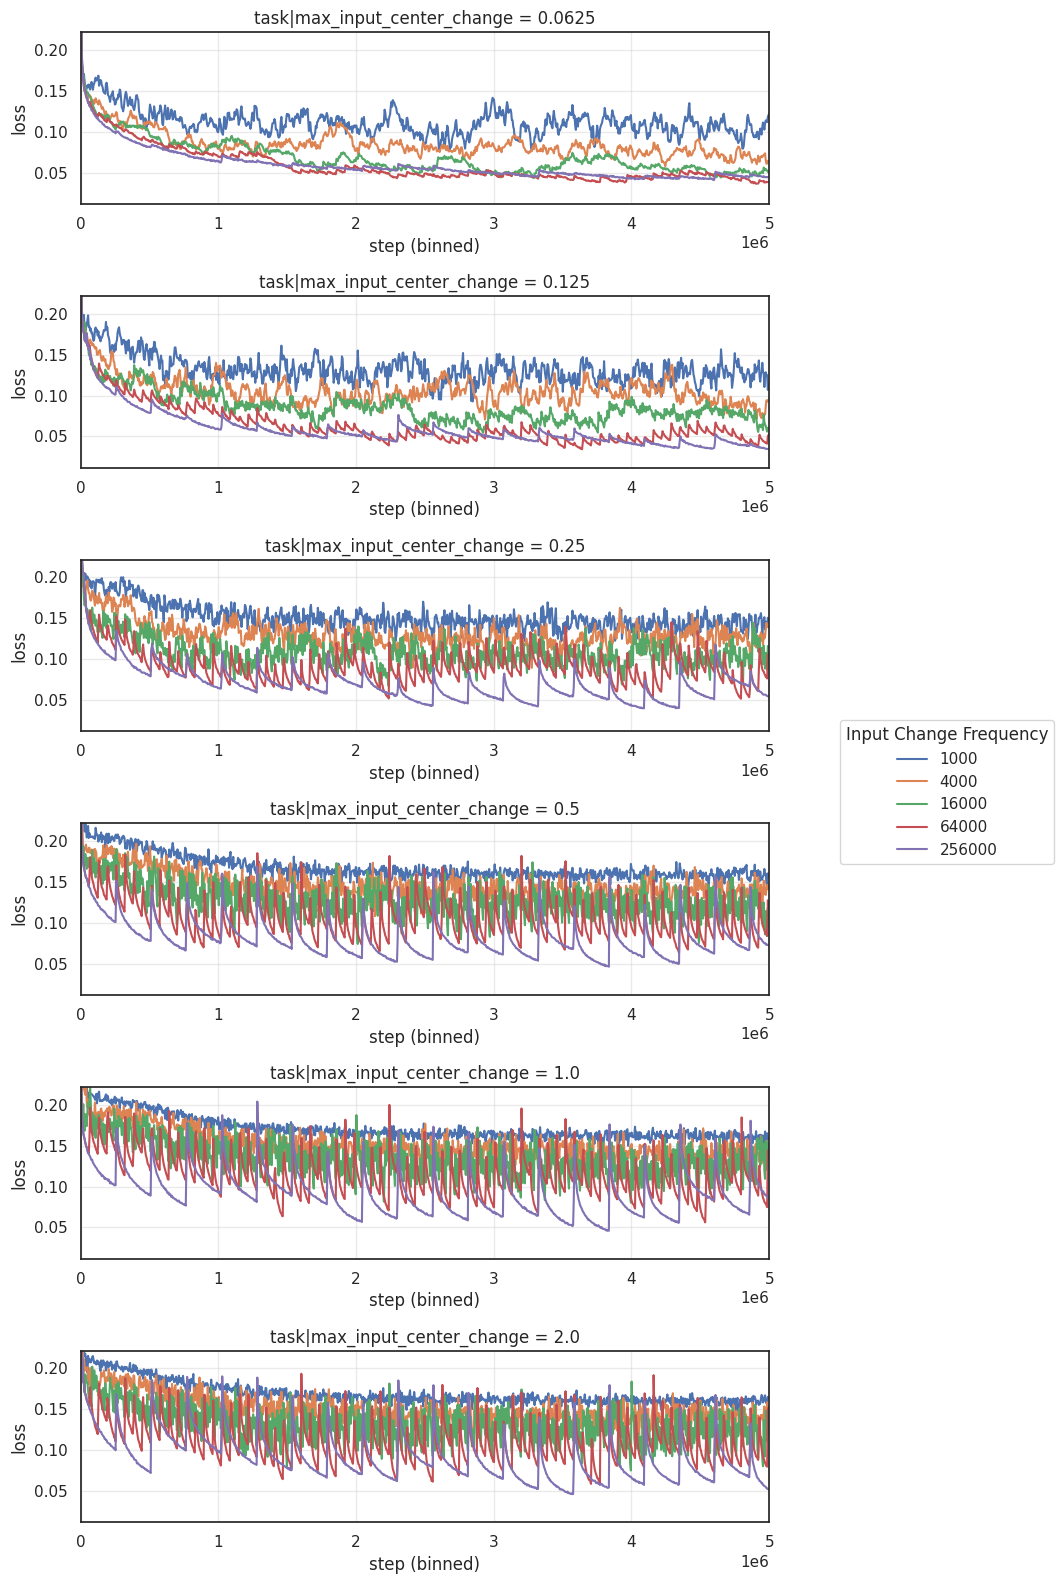

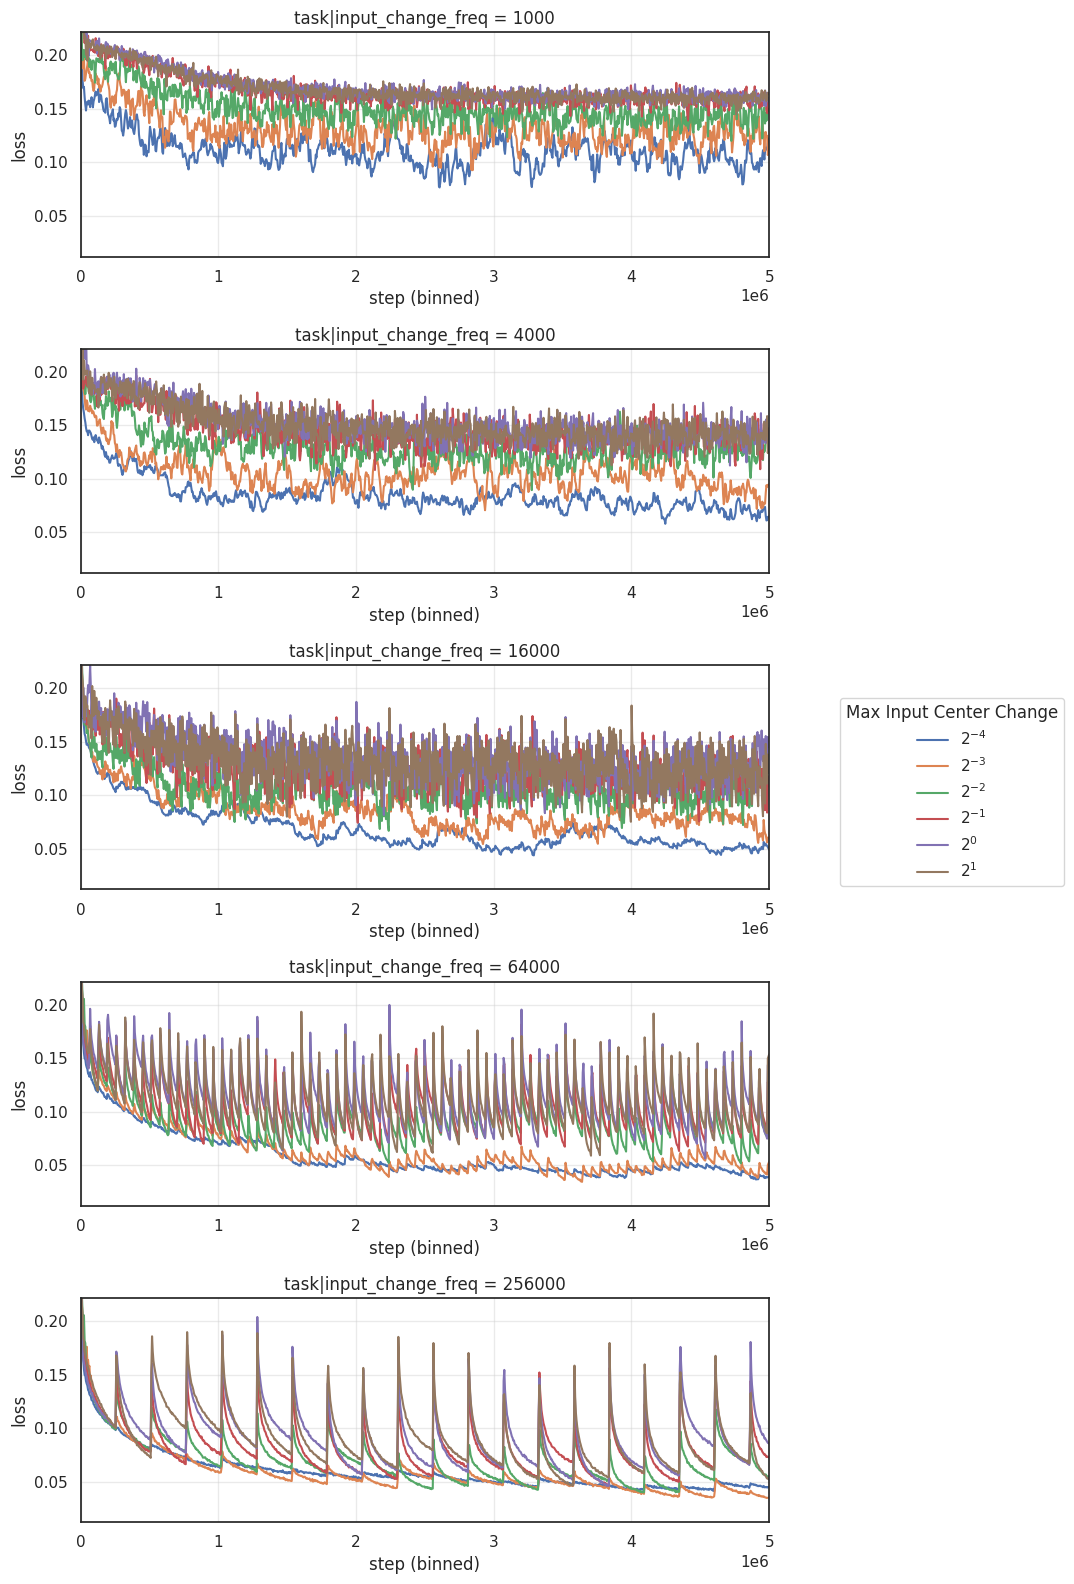

In [39]:
plot_config_df = config_dfs['change_type'].copy()
# plot_config_df['task|max_input_center_change'] = plot_config_df['task|max_input_center_change'].apply(
#     lambda x: '$2^{{{}}}$'.format(int(np.log2(x)))).astype(str)

plot_learning_curves(
    run_df = run_dfs['change_type'],
    config_df = plot_config_df,
    n_bins = 1000,
    figsize = (8, 16),
    max_cols = 1,
    hue_col = 'task|input_change_freq',
    subplot_col = 'task|max_input_center_change',
    legend_title = 'Input Change Frequency',
)
# plt.suptitle('Performance of on Core Transient Task')
plt.show()


plot_learning_curves(
    run_df = run_dfs['change_type'],
    config_df = plot_config_df,
    n_bins = 1000,
    figsize = (8, 16),
    max_cols = 1,
    hue_col = 'task|max_input_center_change',
    subplot_col = 'task|input_change_freq',
    legend_title = 'Max Input Center Change',
    pow_2_legend = True,
)
# plt.suptitle('Performance of on Core Transient Task')
plt.show()

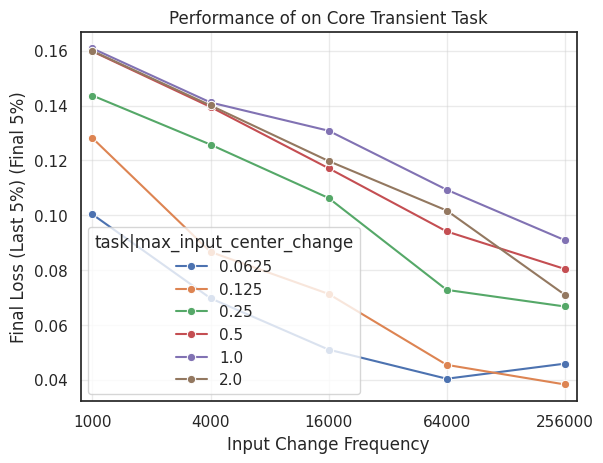

In [ ]:
plot_param_sensitivity(
    run_df = run_dfs['change_type'],
    config_df = plot_config_df,
    x_col = 'task|input_change_freq',
    title = 'Performance on Core Transient Task',
    x_label = 'Input Change Frequency',
    y_label = 'Final Loss (Last 5%)',
    hue_col = 'task|max_input_center_change',
    metric_type = 'final_avg',
    pow_2_legend = True,
)
    